In [5]:
# ===================================================
#  INSTALL DEPENDENCIES
# ===================================================
!pip install torch torchvision torchaudio --upgrade --quiet
!pip install diffusers transformers accelerate safetensors opencv-python pillow --quiet
!pip install timm --quiet

# ===================================================
# IMPORT LIBRARIES
# ===================================================
import torch
import cv2
import numpy as np
from PIL import Image
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
from torchvision import transforms


Using device: cpu


Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master
/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name vit_base_resnet50_384 to current vit_base_r50_s16_384.orig_in21k_ft_in1k.
  model = create_fn(


Downloading: "https://github.com/isl-org/MiDaS/releases/download/v3/dpt_hybrid_384.pt" to /root/.cache/torch/hub/checkpoints/dpt_hybrid_384.pt


100%|██████████| 470M/470M [00:09<00:00, 51.7MB/s]
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


Loading ControlNet & Stable Diffusion...


...

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Generating depth map...


TypeError: unsupported operand type(s) for /: 'Image' and 'float'

In [1]:
# ===================================================
#  INSTALL DEPENDENCIES
# ===================================================
!pip install torch torchvision torchaudio --upgrade --quiet
!pip install diffusers transformers accelerate safetensors opencv-python pillow timm --quiet

# ===================================================
#  IMPORT LIBRARIES
# ===================================================
import torch
import cv2
import numpy as np
from PIL import Image
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel

# ===================================================
#  DEVICE CONFIG
# ===================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ===================================================
#  LOAD MiDaS DEPTH MODEL
# ===================================================
midas = torch.hub.load("intel-isl/MiDaS", "DPT_Hybrid")
midas.to(device)
midas.eval()

midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
transform = getattr(midas_transforms, "dpt_transform", midas_transforms.default_transform)

def get_depth_map(image_path):
    """Generate normalized depth map from layout or room image."""
    img = Image.open(image_path).convert("RGB")
    img_np = np.array(img)  # convert PIL → NumPy
    input_batch = transform(img_np).to(device)

    with torch.no_grad():
        prediction = midas(input_batch)
        prediction = torch.nn.functional.interpolate(
            prediction.unsqueeze(1),
            size=img.size[::-1],
            mode="bicubic",
            align_corners=False,
        ).squeeze()

    depth = prediction.cpu().numpy()
    depth = cv2.normalize(depth, None, 0, 255, cv2.NORM_MINMAX)
    depth = depth.astype(np.uint8)
    depth_img = cv2.cvtColor(depth, cv2.COLOR_GRAY2BGR)
    return depth_img

# ===================================================
#  LOAD CONTROLNET + STABLE DIFFUSION
# ===================================================
print("Loading ControlNet & Stable Diffusion...")

# Load ControlNet first
controlnet = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-depth")
# Cast dtype if needed
if device.type == "cuda":
    controlnet = controlnet.to(torch.float16)

# Load Stable Diffusion pipeline
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet
)
pipe.to(device)
if device.type == "cuda":
    pipe.enable_xformers_memory_efficient_attention()
pipe.enable_attention_slicing()

# ===================================================
#  GENERATION FUNCTION
# ===================================================
def generate_interior_design(layout_path, prompt, output_path="interior_design.png"):
    print("Generating depth map...")
    depth_map = get_depth_map(layout_path)

    print("Generating interior design from prompt...")
    depth_map = cv2.resize(depth_map, (512, 512))

    result = pipe(
    prompt=prompt,
    image=Image.fromarray(depth_map),
    num_inference_steps=20,
    guidance_scale=7.5
    )

    img = result.images[0]
    img.save(output_path)
    print(f" Design saved as {output_path}")
    return img

# ===================================================
#  inference
# ===================================================
layout_image_path = "rooms_1.jpg"  # upload our image path here
prompt = "modern luxury living room with warm wood tones and natural light" # kind of chnage to images
output_image_path = "final_interior.png" # path of chnaged image

image = generate_interior_design(layout_image_path, prompt, output_image_path)
image.show()



Using device: cpu


Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name vit_base_resnet50_384 to current vit_base_r50_s16_384.orig_in21k_ft_in1k.
  model = create_fn(
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


Loading ControlNet & Stable Diffusion...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Generating depth map...
Generating interior design from prompt...


  0%|          | 0/20 [00:00<?, ?it/s]

 Design saved as final_interior.png


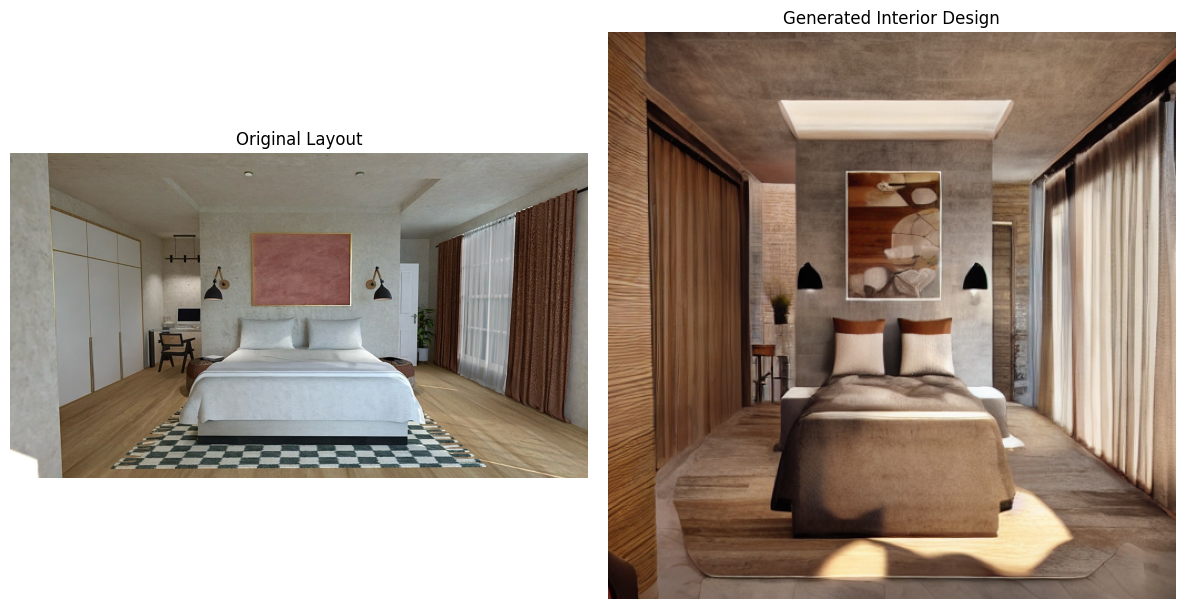

In [2]:
from PIL import Image
import matplotlib.pyplot as plt

# Paths to your images
original_path = layout_image_path          # your original layout image path
generated_path = output_image_path         # the generated output ("final_interior.png")

# Load both images
original_img = Image.open(original_path).convert("RGB")
generated_img = Image.open(generated_path).convert("RGB")

# Create a side-by-side display
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title("Original Layout")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(generated_img)
plt.title("Generated Interior Design")
plt.axis("off")

plt.tight_layout()
plt.show()
